In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Clustering: Jerárquico

### Cargar datos

In [2]:
df = pd.read_csv("hyg_sample.csv")
X = df[["ci", "log_lum"]]
print(X)

        ci  log_lum
0    1.021   1.1288
1    0.614   0.2792
2    1.112   1.4672
3    0.909   1.0468
4    0.580  -3.6920
..     ...      ...
749  1.050   1.2424
750  1.210   1.5828
751  1.378   2.0512
752  1.069   1.7968
753  1.101   0.9260

[754 rows x 2 columns]


### Recomendado: escalar las columnas para que sean comparables 

In [9]:
# Por defecto, StandardScaler convierte cada valor al z-score por columna
# z = (x - mu)/std, donde x es un dato, mu y std son la media y desv. est. de la columna
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Aplicar Clustering Jerárquico

In [10]:
# Aquí debemos dar el número de clusters porque scikitlearn está diseñado para clusterizar
# También podemos darle None y usar distance_threshold para cortar el árbol por distancia
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X_scaled)

### Graficar el resultado (scatter plot)

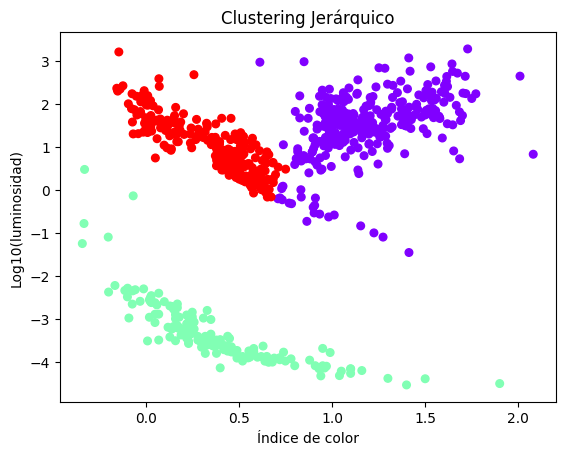

In [5]:
plt.scatter(df['ci'], df['log_lum'], c=labels, cmap='rainbow', s=30)
plt.title('Clustering Jerárquico')
plt.xlabel('Índice de color')
plt.ylabel('Log10(luminosidad)')
plt.show()

### Calcular y graficar el dendograma

In [6]:
# Esto calcula el árbol completo de clustering jerárquico
linked = linkage(X, method='ward')

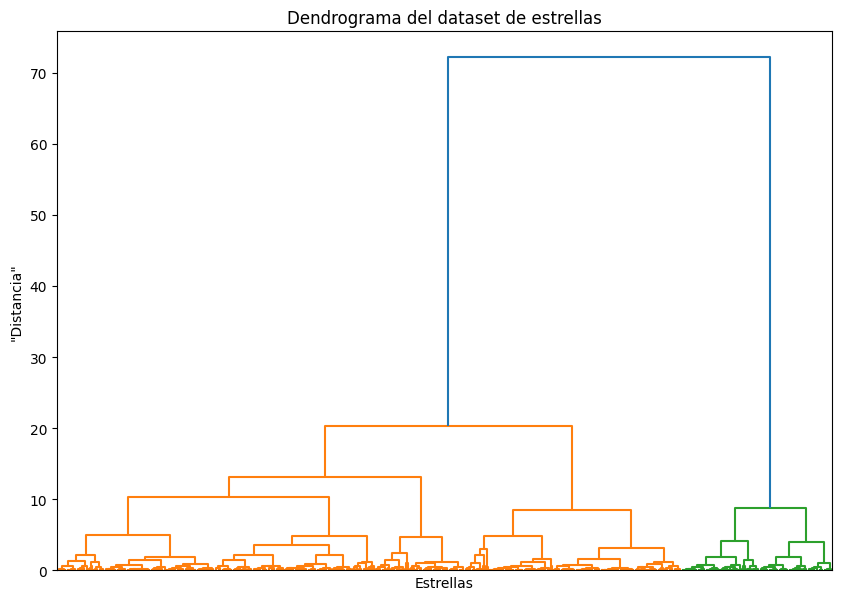

In [8]:
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending')
plt.title('Dendrograma del dataset de estrellas')
plt.xticks([])
plt.xlabel('Estrellas')
plt.ylabel('"Distancia"')
plt.show()